# Measurement Error: Python Practice
**ENGR 1451 / 2451 · Exploratory Data Science · Fall 2026**

Complete this notebook **after the measurement-error slides**. Practice computing summaries,
plotting, selecting observations, and using a normal CDF.

Run cells from top to bottom. All data are embedded; no CSV or download is needed.
Before saving, restart the kernel and run all cells.

In [1]:
# If packages are missing, run: %pip install numpy pandas matplotlib scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

%matplotlib inline

## 1. Load the readings

These are the 100 NB 10 readings from the slides, reported as **micrograms below 10 grams**.
`measurements` is the data table; `shortfall` selects its numeric column.

In [17]:
# Source: Freedman et al., Statistics, Chapter 6, Table 1, p. 99.
shortfall_values = [
    409, 400, 406, 399, 402, 406, 401, 403, 401, 403,
    398, 403, 407, 402, 401, 399, 400, 401, 405, 402,
    408, 399, 399, 402, 399, 397, 407, 401, 399, 401,
    403, 400, 410, 401, 407, 423, 406, 406, 402, 405,
    405, 409, 399, 402, 407, 406, 413, 409, 404, 402,
    404, 406, 407, 405, 411, 410, 410, 410, 401, 402,
    404, 405, 392, 407, 406, 404, 403, 408, 404, 407,
    412, 406, 409, 400, 408, 404, 401, 404, 408, 406,
    408, 406, 401, 412, 393, 437, 418, 415, 404, 401,
    401, 407, 412, 375, 409, 406, 398, 406, 403, 404,
]
observation_count = len(shortfall_values)

measurements = pd.DataFrame({
    "measurement_no": np.arange(1, observation_count+1),
    "shortfall_ug": shortfall_values,
})
shortfall = measurements["shortfall_ug"]
measurements.head()

,measurement_no,shortfall_ug
0,1,409
1,2,400
2,3,406
3,4,399
4,5,402


## 2. Compute the mean and sample standard deviation

Use `mean()` for $\bar{x}$ and `std(ddof=1)` for sample $s$.
The `ddof=1` argument makes the divisor $n-1$.

In [3]:
mean_shortfall = shortfall.mean()
s_shortfall = shortfall.std(ddof=1)

print(f"Mean shortfall = {mean_shortfall:.3f} µg")
print(f"Sample s = {s_shortfall:.3f} µg")

Mean shortfall = 404.590 µg
Sample s = 6.467 µg


## 3. Make two plots

Use `ax.scatter()` for readings versus measurement number.
For the histogram, `density=True` puts the bars on the same scale as `norm.pdf()`.

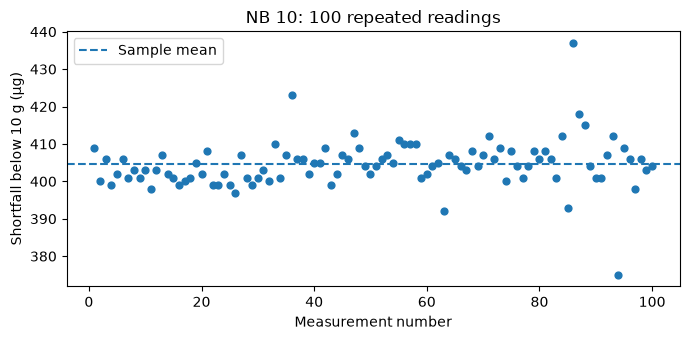

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(measurements["measurement_no"], shortfall, s=24)
ax.axhline(mean_shortfall, linestyle="--", label="Sample mean")
ax.set(xlabel="Measurement number", ylabel="Shortfall below 10 g (µg)",
       title="NB 10: 100 repeated readings")
ax.legend()
fig.tight_layout()
plt.show()

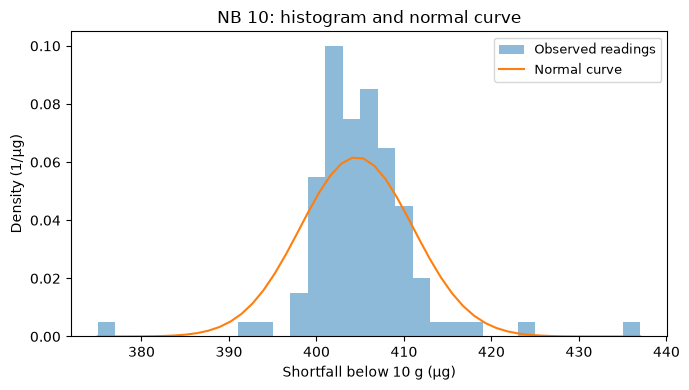

In [12]:
edges = np.arange(shortfall.min(), shortfall.max()+2, 2)
x = np.linspace(shortfall.min(), shortfall.max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(shortfall, bins=edges, density=True, alpha=0.5, label="Observed readings")
ax.plot(x, norm.pdf(x, loc=mean_shortfall, scale=s_shortfall),
        label="Normal curve")
ax.set(xlabel="Shortfall below 10 g (µg)", ylabel="Density (1/µg)",
       title="NB 10: histogram and normal curve")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 4. Count observations and use `norm.cdf()`

`between(..., inclusive="both")` includes both endpoints, matching the revised slides.
For a Boolean mask, `sum()` counts the selected readings and `mean()` gives their fraction.

Use the slides' **rounded center 405 and SD 6** for this calculation;
the plot above uses the calculated mean and sample standard deviation.

In [ ]:
lower, upper = 400, 406
in_range = shortfall.between(lower, upper, inclusive="both")

probability = (
    norm.cdf(upper, loc=405, scale=6)
    - norm.cdf(lower, loc=405, scale=6)
)
estimated_count = len(shortfall) * probability

print(f"Observed count, including both endpoints: {in_range.sum()}")
print(f"Observed percentage: {100 * in_range.mean():.1f}%")
print(f"Normal estimate: {estimated_count:.1f} readings")

## 5. Select rows without changing the original data

`isin()` identifies measurement IDs, `~` reverses the mask, and `.loc[]` selects rows.
Create a separate comparison subset for the three observations discussed in the slides.
**This is a sensitivity check, not an automatic deletion rule.**

`agg()` runs several summaries at once; its pandas `"std"` summary uses `ddof=1`.
Mean and standard deviation below are in µg.

In [ ]:
is_extreme = measurements["measurement_no"].isin([36, 86, 94])
measurements.loc[is_extreme]

In [ ]:
subset_shortfall = measurements.loc[~is_extreme, "shortfall_ug"].copy()

comparison = pd.DataFrame({
    "All 100 readings": shortfall.agg(["count", "mean", "std"]),
    "97-reading comparison": subset_shortfall.agg(["count", "mean", "std"]),
})
comparison.round(3)

## Practice: repeated calibration, chance error, and bias

A laboratory calibrates the same yardstick three times and obtains:

**35.96, 36.01, 36.03 inches**

1. Create a `pd.Series` containing the three measurements.
2. Use `agg()` to find the mean and sample standard deviation $s$.
3. Based on the standard deviation, a fourth measurement would likely be **36 inches give or take about how much?**
   - 0.01 inches
   - 0.03 inches
   - 0.06 inches
4. Does repeating the measurement tell us whether the laboratory has **bias**? Explain.

**Bias check:** Suppose a cloth tape intended to be 36 inches long has stretched to 37 inches. Is this **chance error** or **bias**? Would repeating the measurement eliminate the problem?



In [19]:
calibrations = pd.Series([35.96, 36.01, 36.03], name="calibration_in")
calibrations.agg(["mean","std"])

# Your code: use agg() to find the mean and sample standard deviation.


mean    36.000000
std      0.036056
Name: calibration_in, dtype: float64

## Compact Python reference

| Task | Python pattern |
|:--|:--|
| Select a column | `df["column"]` |
| Mean and sample $s$ | `values.mean()`; `values.std(ddof=1)` |
| Several summaries | `values.agg(["count", "mean", "std"])` |
| Inclusive interval mask | `mask = values.between(a, b, inclusive="both")` |
| Count / fraction selected | `mask.sum()` / `mask.mean()` |
| Match measurement IDs | `mask = df["measurement_no"].isin(ids)` |
| Copy the other rows | `df.loc[~mask].copy()` |
| Scatterplot / density histogram | `ax.scatter(x, y)` / `ax.hist(values, bins=edges, density=True)` |
| Normal density | `norm.pdf(x, loc=center, scale=spread)` |
| Normal CDF | `norm.cdf(x, loc=center, scale=spread)` |

Subtract two CDF values to get a normal interval probability.